In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.linear_model import Ridge


np.random.seed(42)

n = 30  # Sample size
x = np.random.uniform(0, 10, n)
X = np.vstack([x, np.ones(n)]).T  # Add intercept term
theta_true = np.array([2.0, 5.0])  # Slope 2, intercept 5
y = X @ theta_true + np.random.normal(0, 1.0, n)


$$
\begin{align}
\theta_{MAP} &= \arg \min_{\theta} \sum_{i=1}^n (y_i - \theta^T x_i)^2 + \lambda || \theta ||^2  \quad\text{where}\quad \lambda = \frac{\sigma^2}{\tau^2}  \\
\end{align}
$$

In [31]:
# ------------------------------------------------------------
# MAP推定（Ridge回帰）の損失関数を定義
# ------------------------------------------------------------
def map_loss(theta: np.ndarray, X: np.ndarray, y: np.ndarray, lambda_: float) -> float:
    """
    MAP推定（Ridge回帰）の損失関数を計算する。

    Args:
        theta (np.ndarray): パラメータベクトル（形状: [特徴量数]）
        X (np.ndarray): 説明変数のデザイン行列（形状: [サンプル数, 特徴量数]）
        y (np.ndarray): 目的変数ベクトル（形状: [サンプル数]）
        lambda_ (float): 正則化パラメータ

    Returns:
        float: 損失関数の値（残差二乗和 + 正則化項）
    """
    pred = X @ theta
    residual = y - pred
    return np.sum(residual**2) + lambda_ * np.sum(theta**2)

# ------------------------------------------------------------
# MAP推定の正則化パラメータを設定
# ------------------------------------------------------------
lambda_ = 5.0  # 正則化パラメータ（= σ²/τ²）

# ------------------------------------------------------------
# パラメータの初期値（ゼロベクトル）を設定
# ------------------------------------------------------------
theta_init: np.ndarray = np.zeros(X.shape[1])

# ------------------------------------------------------------
# MAP推定（損失最小化による推定値の算出）
# ------------------------------------------------------------
res = minimize(map_loss, x0=theta_init, args=(X, y, lambda_))
theta_map: np.ndarray = res.x

# ------------------------------------------------------------
# scikit-learnのRidge回帰による推定
# ------------------------------------------------------------
ridge = Ridge(alpha=lambda_, fit_intercept=False)
ridge.fit(X, y)
theta_ridge: np.ndarray = ridge.coef_

# ------------------------------------------------------------
# MAP推定の閉形式解（closed-form solution）を計算
# ------------------------------------------------------------
lambda_ = 1.0  # 閉形式解用の正則化パラメータ
I: np.ndarray = np.eye(X.shape[1])  # 単位行列（切片も含む）
theta_cf: np.ndarray = np.linalg.inv(X.T @ X + lambda_ * I) @ (X.T @ y)

# ------------------------------------------------------------
# 結果を出力
# ------------------------------------------------------------
print(f"Closed-form solution(MAP): {theta_cf}")
print(f"Scratch estimate(MAP): {theta_map}")
print(f"scikit-learn Ridge: {theta_ridge}")

Closed-form solution(MAP): [1.9451173  4.89550129]
Scratch estimate(MAP): [2.15167535 3.55947999]
scikit-learn Ridge: [2.15167537 3.55947995]


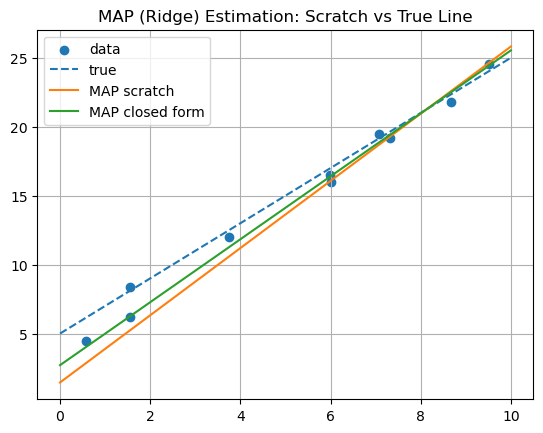

In [28]:
xline = np.linspace(0, 10, 100)
y_true_line = theta_true[0] * xline + theta_true[1]
y_map_line = theta_map[0] * xline + theta_map[1]
y_map_line_cf = theta_cf[0] * xline + theta_cf[1]

plt.scatter(x, y, label="data")
plt.plot(xline, y_true_line, "--", label="true")
plt.plot(xline, y_map_line, "-", label="MAP scratch")
plt.plot(xline, y_map_line_cf, "-", label="MAP closed form")
plt.legend()
plt.grid(True)
plt.title("MAP (Ridge) Estimation: Scratch vs True Line")
plt.show()